In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[-36.98934527 -11.50074388  11.58095799  32.59195853  45.46546913
  72.42959233  73.45563211 123.30906674 123.31714132 190.13524311
 190.13526154]


In [30]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["font.size"] = 26

plt.rcParams["mathtext.fontset"] = "stix"

## Simulaatio

In [21]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän kulmataajuus
f_1=1.2*qubit.frequency
f_2=1.4*qubit.frequency

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [23]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.one],[N_pulse],time_unit=dt,offset_input=0)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1
    
    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    psi = np.zeros(dim, dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0] = 1
    
    #Simulaatio pulsseille
    for i in range(0,N_sim):
        psi = U_floquet @ psi #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla
        last_vals.append(evolution.U(0,10) @ psi)

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in last_vals])
    f_vals = np.array([np.abs(a[2])**2 for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def sim_pulse_2(f_1,f_2,A,evolution,dim,f_rabi,K=20):
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_1,f_ef,[pulses.one],[N_pulse],time_unit=dt,second_frequency=f_2)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1
    
    psi = np.zeros((N_sim, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0,0] = 1
    
    #Simulaatio pulsseille
    for i in range(1,N_sim):
        psi[i] = U_floquet @ psi[i-1] #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in psi])
    f_vals = np.array([np.abs(a[2])**2 for a in psi])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,psi,pulse_times)

def sim_pulse_sub(f_d,A,evolution,dim,f_rabi,K=20):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.one],[N_pulse],time_unit=dt,offset_input=0)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    psi = np.zeros(dim, dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0] = 1
    
    #Simulaatio pulsseille
    for i in range(0,N_sim):
        psi = U_floquet @ psi #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla
        last_vals.append(psi)

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in last_vals])
    f_vals = np.array([np.abs(a[2])**2 for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def lorentzian(x, x0, gamma, A, y0):
    return A * (gamma**2 / ((x - x0)**2 + gamma**2)) + y0


def find_params(q,A,evolution,f_rabi):

    #Rajat AC-stark siirtymälle
    min_range = -400
    max_range = 400

    f_d = q.frequency #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=i/10000 #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_d+delta,A,evolution,dim,f_rabi)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    #plt.figure()
    #plt.plot(AC_stark_vals, max_e_vals)
    #print(AC_stark_vals, max_e_vals)
    #plt.xlabel("$\delta$ (GHz)")
    #plt.ylabel("Maximum population of the e-state")
    
    #ax = plt.gca()
    
    #ax.text(0.02, 0.98, "(a)",
    #    transform=ax.transAxes,
    #    va="top",
    #    fontweight="bold",
    #    fontsize=16)
    
    #plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

def find_params_2(q,A,evolution,f_rabi,c_guess):

    #Rajat AC-stark siirtymälle
    min_range = -200
    max_range = 200
    
    scale = 20000
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range,max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse_2(f_1_shifted,f_2_shifted,A,evolution,dim,f_rabi,K=200)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    #plt.figure()
    #plt.plot(AC_stark_vals, max_e_vals)
    #print(AC_stark_vals)
    #print(max_e_vals)
    #plt.xlabel("$\delta$ (GHz)")
    #plt.ylabel("Maximum population of the e-state")
    
    ax = plt.gca()
    
    #ax.text(0.02, 0.98, "(c)",
    #    transform=ax.transAxes,
    #    va="top",
    #   fontweight="bold",
    #    fontsize=16)
    
    #plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

def find_params_sub(q,A,evolution,f_rabi,AC_stark):

    #Rajat AC-stark siirtymälle
    min_range = -400
    max_range = 400

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/10000 #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse_sub(f_d+delta,A,evolution,dim,f_rabi)
            
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    #plt.figure()
    #plt.plot(AC_stark_vals, max_e_vals)
    #print(AC_stark_vals)
    #print("-----")
    #print(max_e_vals)
    #plt.xlabel("$\delta$ (GHz)")
    #plt.ylabel("Maximum population of the e-state")
    
    #ax = plt.gca()
    
    #ax.text(0.02, 0.98, "(b)",
    #    transform=ax.transAxes,
    #    va="top",
    #   fontweight="bold",
    #    fontsize=16)
    
    #plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

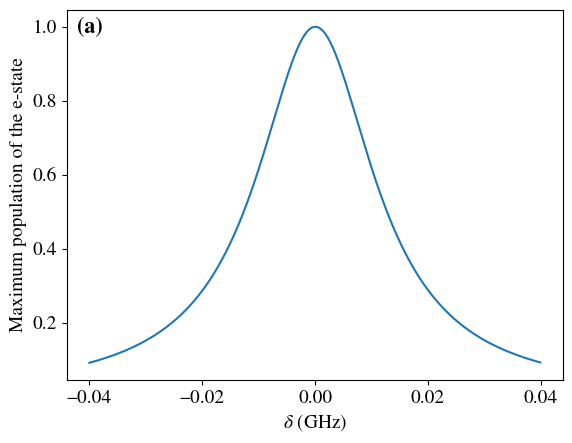

Amplitudi (GHz): 0.012744300694754308
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.999976518577111
Pulssin pituus (ns): 247.24914352088032
Rabi-taajuus (fourier):  0.002028318451819624


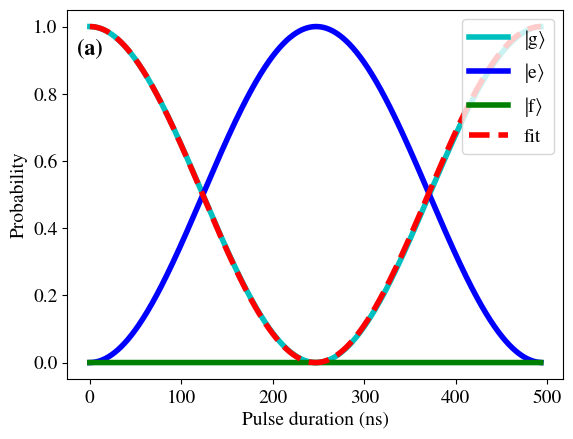

---------------------------------------------


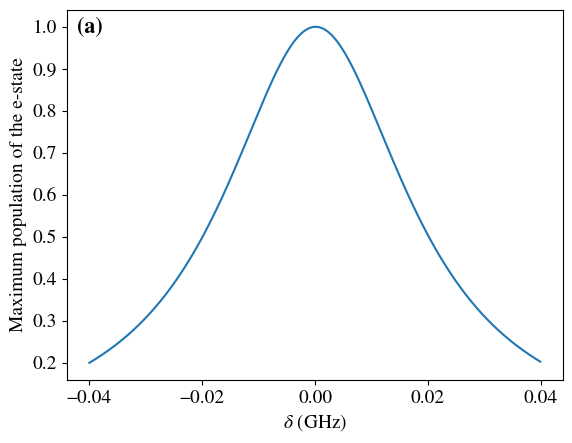

Amplitudi (GHz): 0.020122580044348908
AC-stark siirtymä (GHz): 0.0001
E-tason suurin todennäköisyys: 0.9999619780279758
Pulssin pituus (ns): 156.5329911904137
Rabi-taajuus (fourier):  0.0032025869352429637


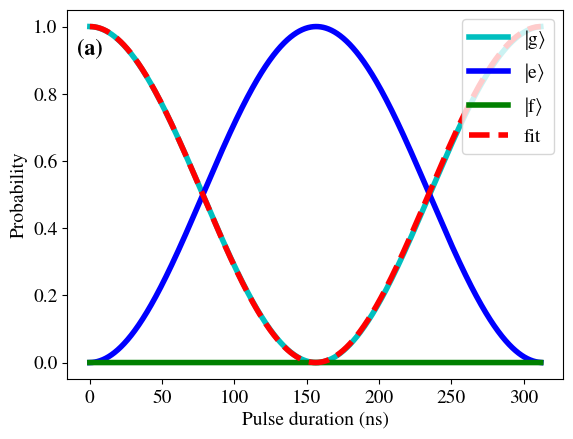

---------------------------------------------


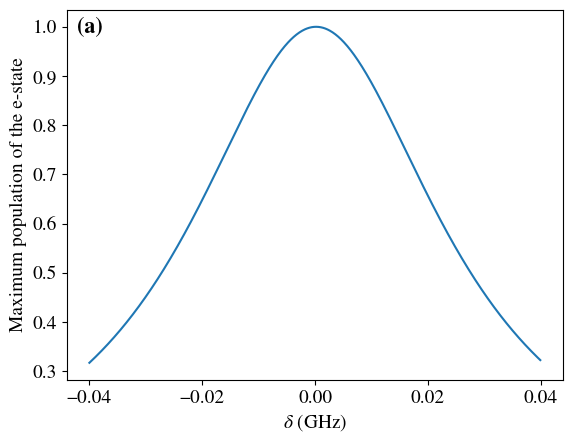

Amplitudi (GHz): 0.027500859393943505
AC-stark siirtymä (GHz): 0.0002
E-tason suurin todennäköisyys: 0.9999283182743017
Pulssin pituus (ns): 114.3795637142564
Rabi-taajuus (fourier):  0.004376881376103607


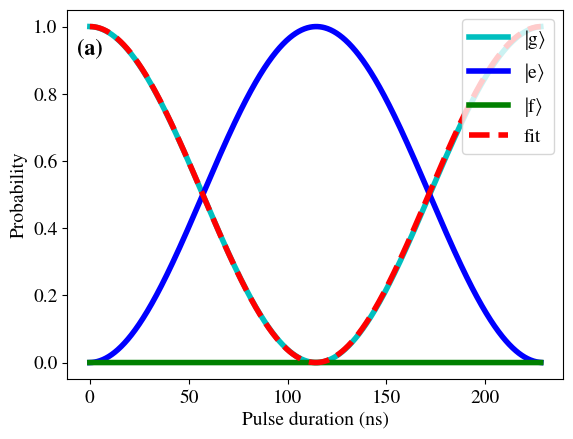

---------------------------------------------


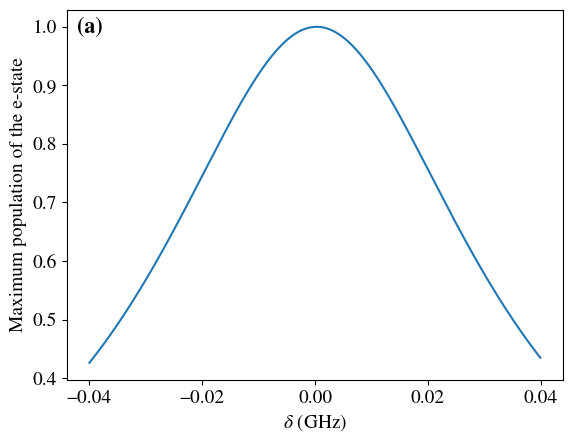

Amplitudi (GHz): 0.0348791387435381
AC-stark siirtymä (GHz): 0.0003
E-tason suurin todennäköisyys: 0.9998865323804116
Pulssin pituus (ns): 90.22145706814483
Rabi-taajuus (fourier):  0.005551170872385911


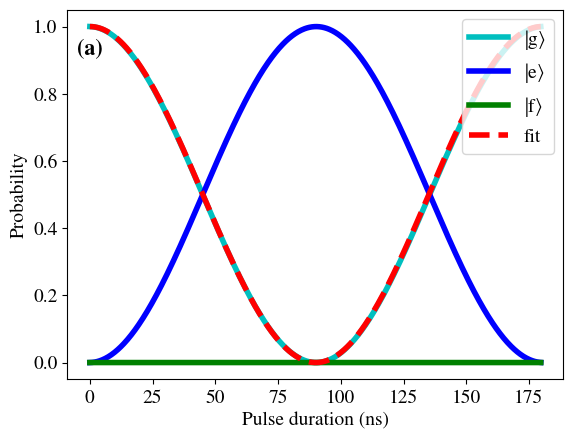

---------------------------------------------


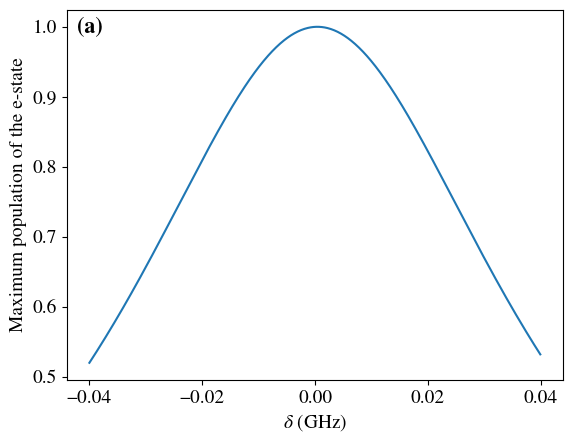

Amplitudi (GHz): 0.0422574180931327
AC-stark siirtymä (GHz): 0.0004
E-tason suurin todennäköisyys: 0.9998301371009517
Pulssin pituus (ns): 74.44473534962667
Rabi-taajuus (fourier):  0.006725410841719002


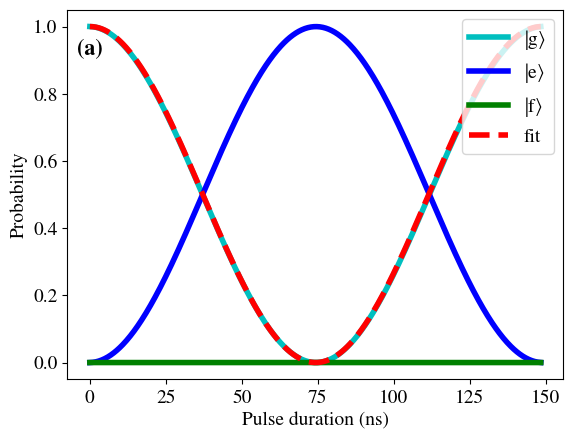

---------------------------------------------


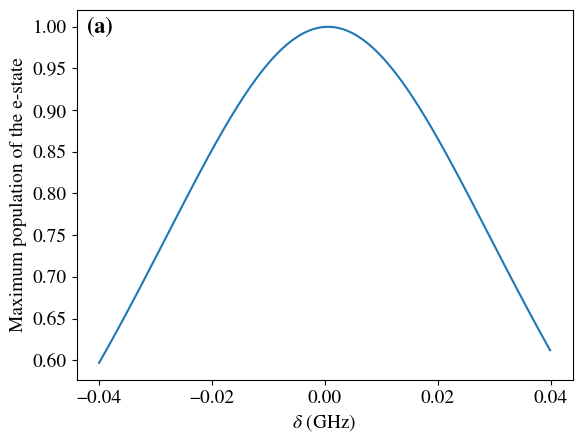

Amplitudi (GHz): 0.049635697442727306
AC-stark siirtymä (GHz): 0.0006
E-tason suurin todennäköisyys: 0.9997719615225663
Pulssin pituus (ns): 63.3514796822861
Rabi-taajuus (fourier):  0.007899698939896605


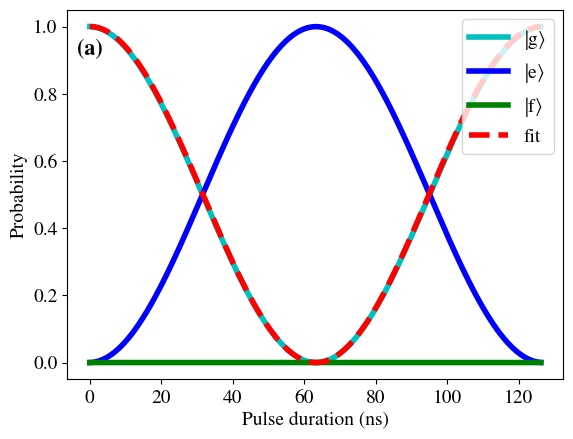

---------------------------------------------


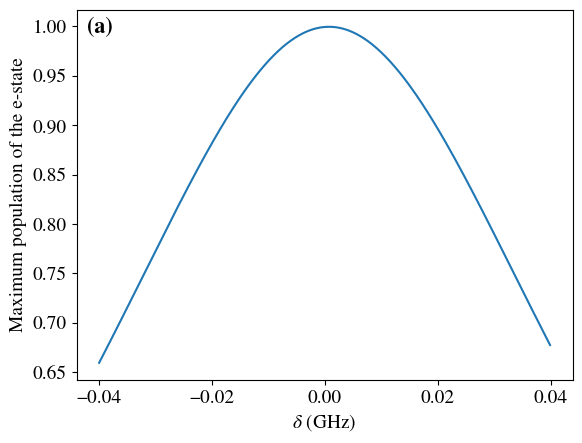

Amplitudi (GHz): 0.0570139767923219
AC-stark siirtymä (GHz): 0.0007
E-tason suurin todennäköisyys: 0.9997009964756951
Pulssin pituus (ns): 54.97013441403147
Rabi-taajuus (fourier):  0.009073875619798274


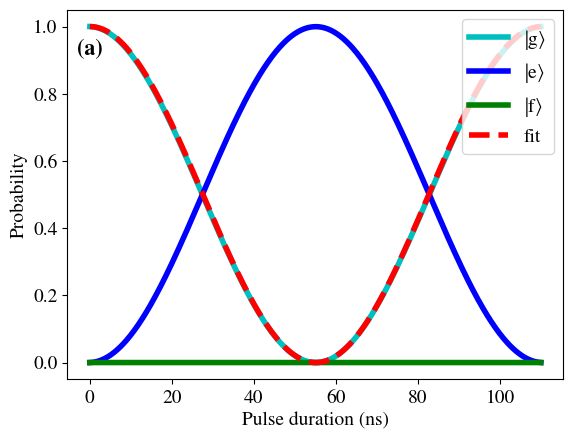

---------------------------------------------


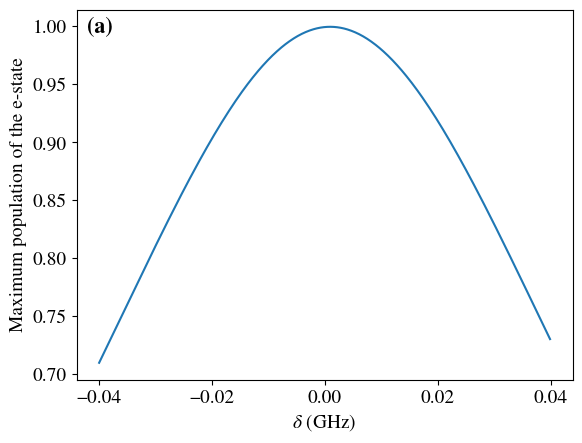

Amplitudi (GHz): 0.0643922561419165
AC-stark siirtymä (GHz): 0.0009
E-tason suurin todennäköisyys: 0.9996200434836772
Pulssin pituus (ns): 48.80718032929482
Rabi-taajuus (fourier):  0.010248276223539299


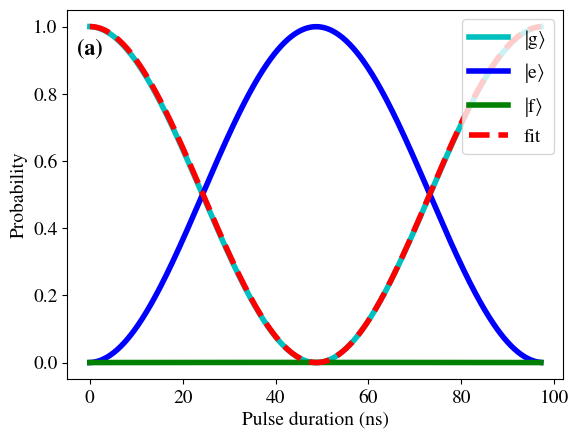

---------------------------------------------


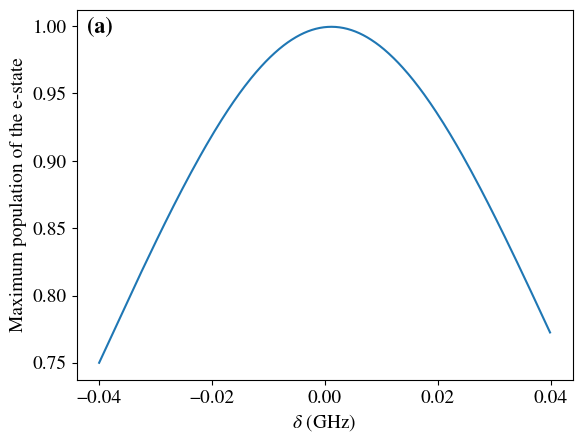

Amplitudi (GHz): 0.07177053549151109
AC-stark siirtymä (GHz): 0.0012
E-tason suurin todennäköisyys: 0.9995293684919255
Pulssin pituus (ns): 43.630147696189084
Rabi-taajuus (fourier):  0.01142253601073026


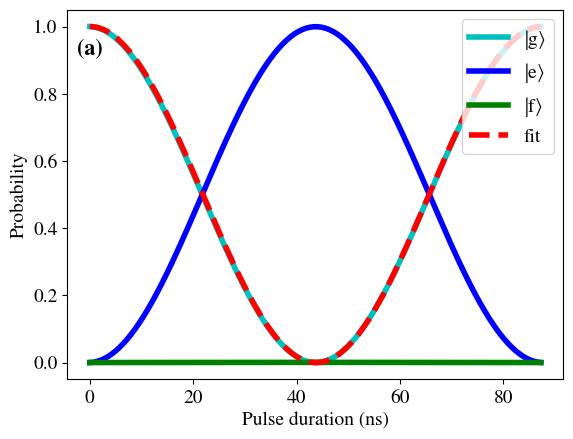

---------------------------------------------


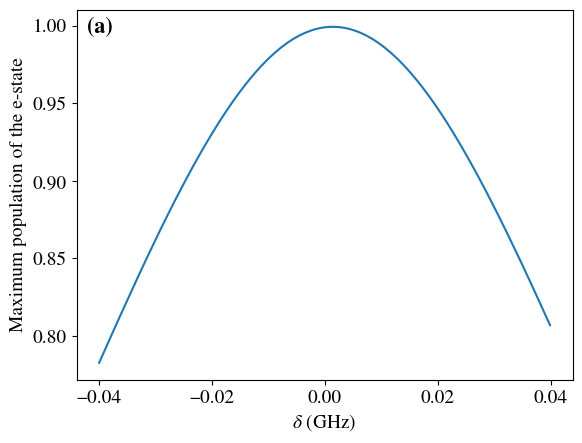

Amplitudi (GHz): 0.0791488148411057
AC-stark siirtymä (GHz): 0.0014
E-tason suurin todennäköisyys: 0.9994295193958543
Pulssin pituus (ns): 39.68586815661269
Rabi-taajuus (fourier):  0.012596596039742836


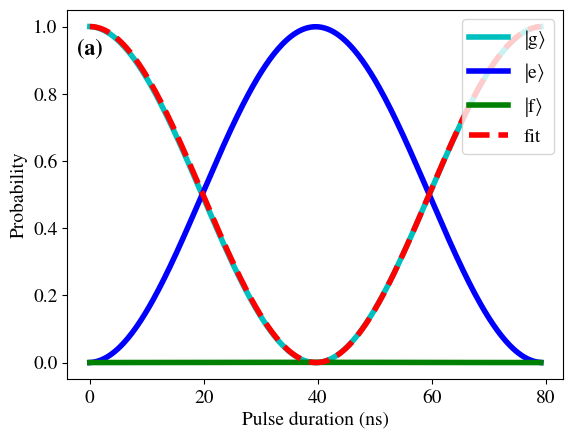

---------------------------------------------


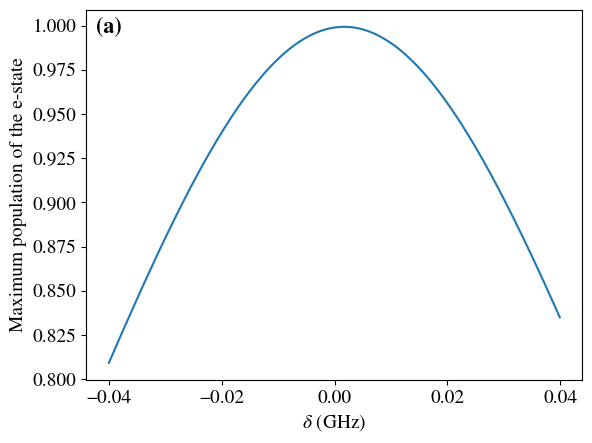

Amplitudi (GHz): 0.0865270941907003
AC-stark siirtymä (GHz): 0.0017
E-tason suurin todennäköisyys: 0.9993211508044244
Pulssin pituus (ns): 36.23449664410595
Rabi-taajuus (fourier):  0.013770901110123912


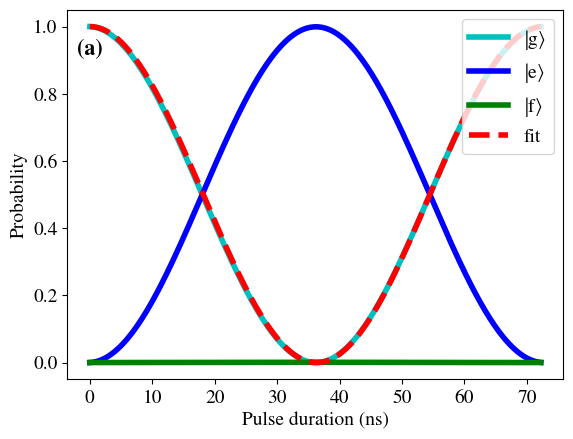

---------------------------------------------


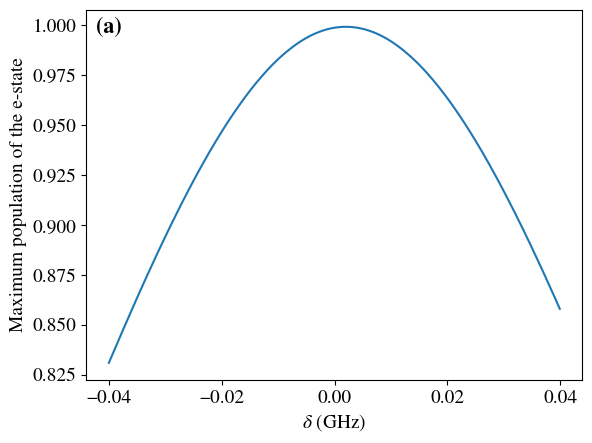

Amplitudi (GHz): 0.0939053735402949
AC-stark siirtymä (GHz): 0.002
E-tason suurin todennäköisyys: 0.9992028610125349
Pulssin pituus (ns): 33.276186917204605
Rabi-taajuus (fourier):  0.014945497194788845


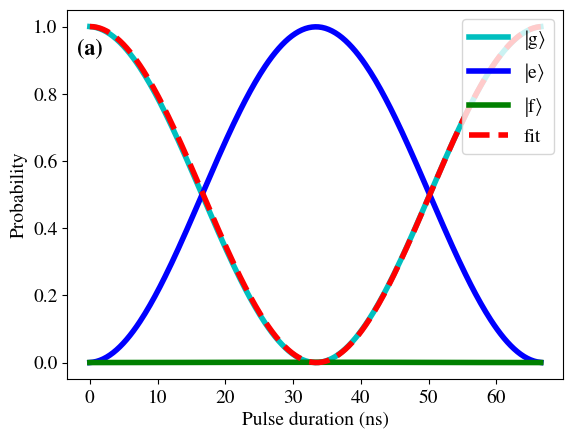

---------------------------------------------


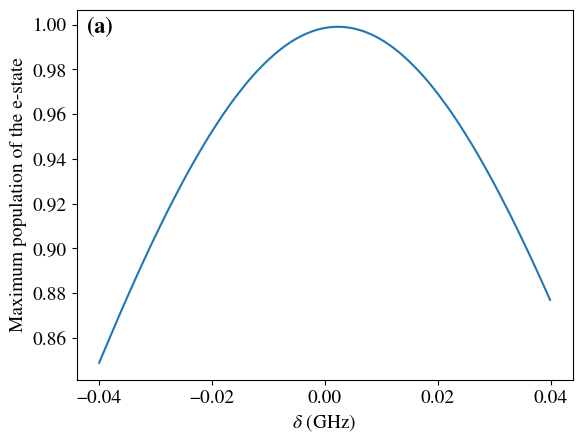

Amplitudi (GHz): 0.10128365288988948
AC-stark siirtymä (GHz): 0.0023
E-tason suurin todennäköisyys: 0.9990760979221027
Pulssin pituus (ns): 30.810921567516534
Rabi-taajuus (fourier):  0.01611968753976621


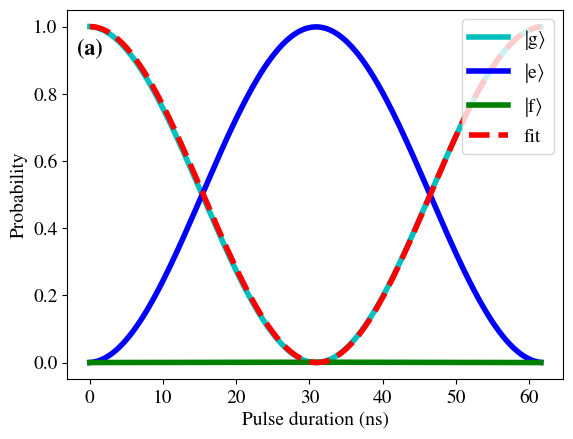

---------------------------------------------


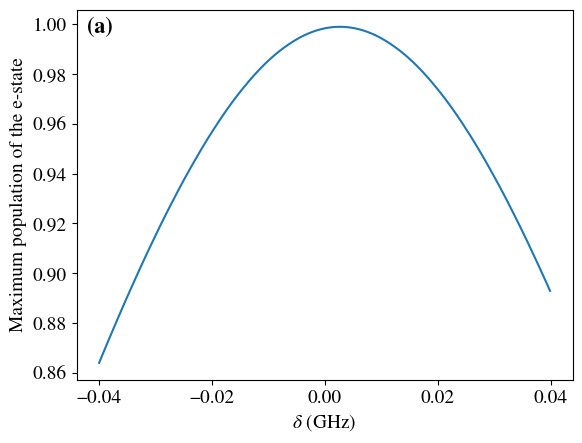

Amplitudi (GHz): 0.1086619322394841
AC-stark siirtymä (GHz): 0.0027
E-tason suurin todennäköisyys: 0.998940354752741
Pulssin pituus (ns): 28.838570056002244
Rabi-taajuus (fourier):  0.01729354911332309


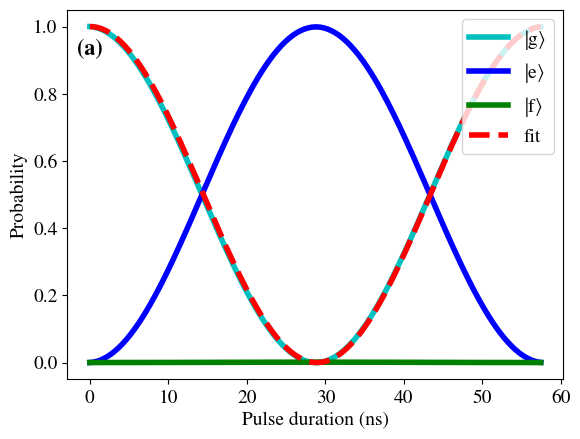

---------------------------------------------


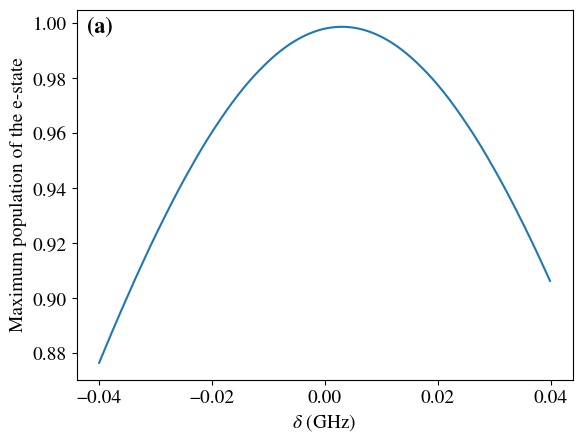

Amplitudi (GHz): 0.11604021158907872
AC-stark siirtymä (GHz): 0.003
E-tason suurin todennäköisyys: 0.9987944623861129
Pulssin pituus (ns): 26.86638583500056
Rabi-taajuus (fourier):  0.01846829191764623


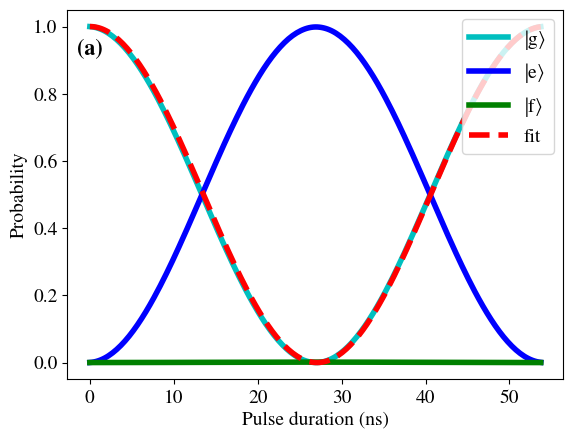

---------------------------------------------


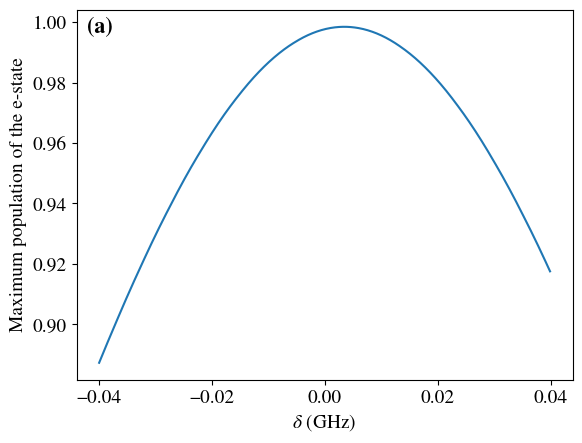

Amplitudi (GHz): 0.12341849093867328
AC-stark siirtymä (GHz): 0.0034
E-tason suurin todennäköisyys: 0.9986329643419887
Pulssin pituus (ns): 25.38710385077271
Rabi-taajuus (fourier):  0.019642595160715377


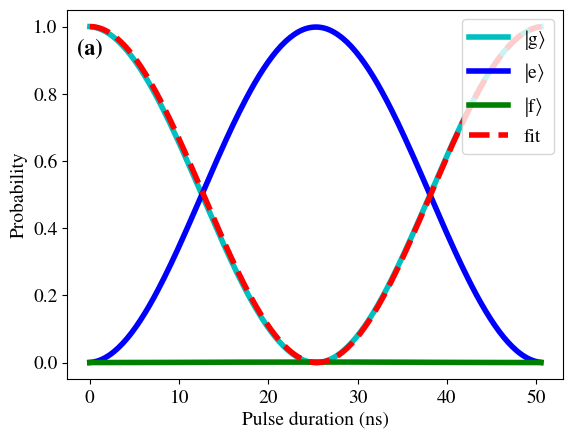

---------------------------------------------


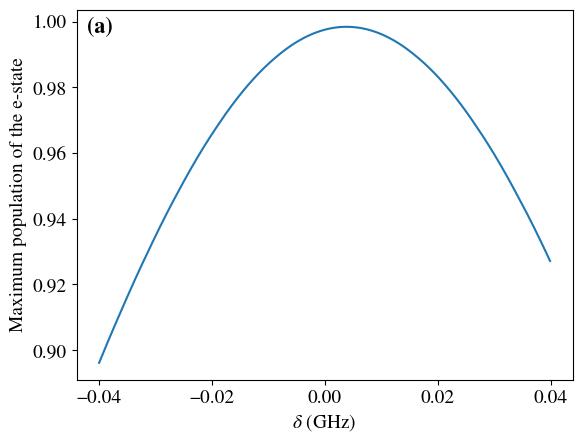

Amplitudi (GHz): 0.1307967702882679
AC-stark siirtymä (GHz): 0.0038
E-tason suurin todennäköisyys: 0.9984776543296336
Pulssin pituus (ns): 23.907868289224666
Rabi-taajuus (fourier):  0.02081597502654044


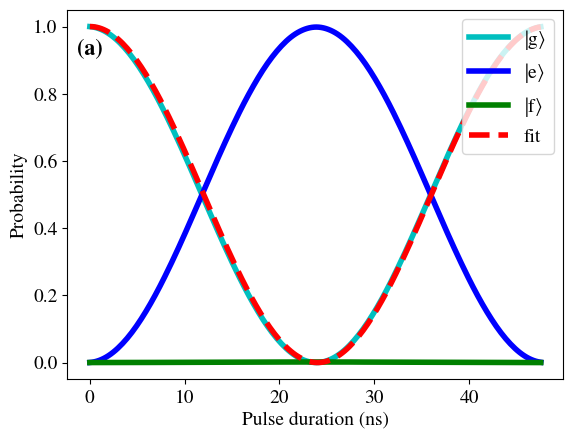

---------------------------------------------


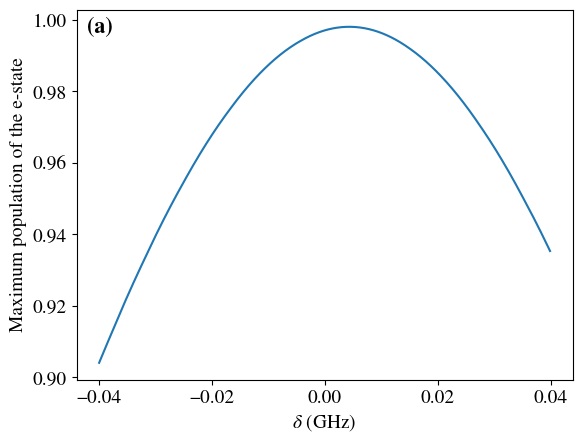

Amplitudi (GHz): 0.13817504963786248
AC-stark siirtymä (GHz): 0.0043
E-tason suurin todennäköisyys: 0.9983111693142702
Pulssin pituus (ns): 22.67505920288911
Rabi-taajuus (fourier):  0.021990901191840346


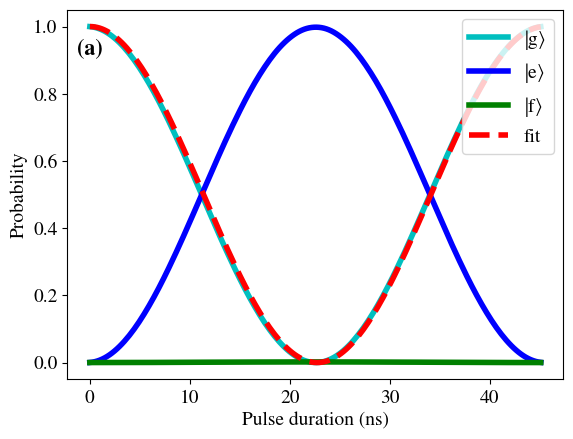

---------------------------------------------


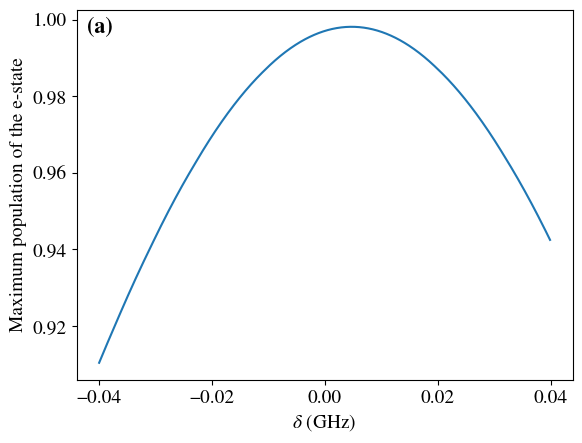

Amplitudi (GHz): 0.1455533289874571
AC-stark siirtymä (GHz): 0.0047
E-tason suurin todennäköisyys: 0.9981250265684708
Pulssin pituus (ns): 21.44238258406125
Rabi-taajuus (fourier):  0.02316520086709552


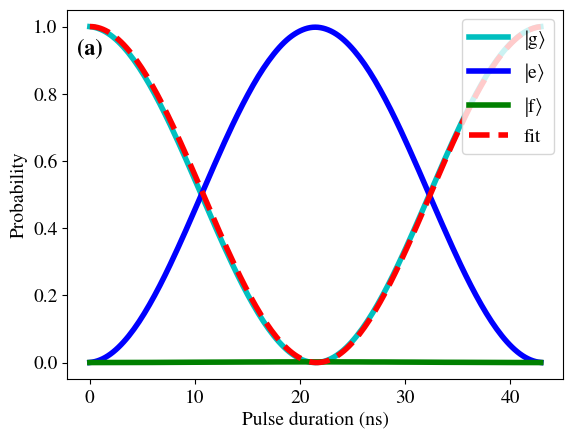

---------------------------------------------


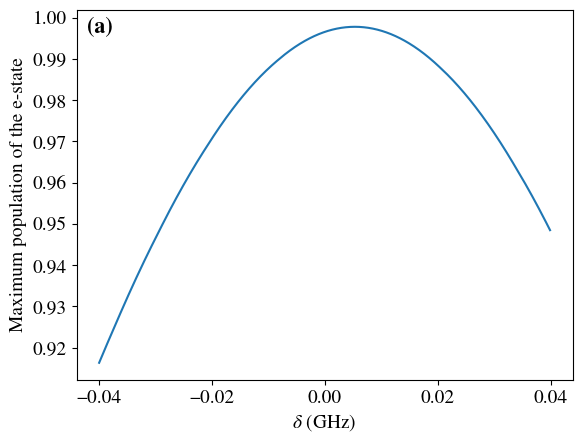

Amplitudi (GHz): 0.1529316083370517
AC-stark siirtymä (GHz): 0.0053
E-tason suurin todennäköisyys: 0.9979425831009394
Pulssin pituus (ns): 20.456044468365203
Rabi-taajuus (fourier):  0.02409516897960086


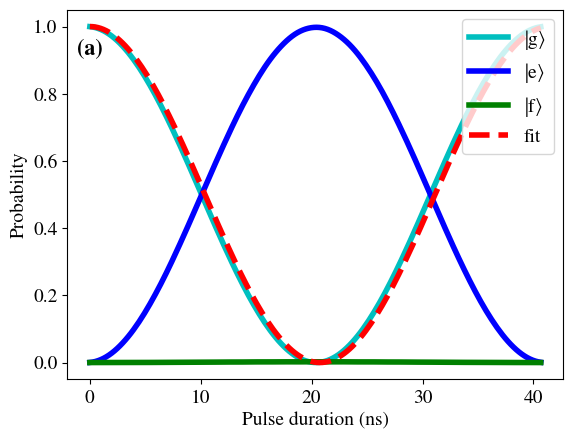

---------------------------------------------


In [11]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0060
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    params=find_params(qubit, A, evolution_eigenbasis,A)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

    vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,A/100)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
    e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
    f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 2*np.pi/(f_d_opt)
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/100) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
    plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
    plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
    plt.plot(vals[4][:n_picked], plot_vals, ls='--', linewidth=4, color='r')
    plt.xlabel("Pulse duration (ns)")
    plt.ylabel("Probability")
    plt.legend(
        [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],
        loc="upper right"
    )
    #print(vals[4][:n_picked])
    #print(g_vals[:n_picked])
    #print(f_vals[:n_picked])
    #print(e_vals[:n_picked])
    
    ax = plt.gca()

    ax.text(0.02, 0.92, "(a)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
        fontsize=16)
    #plt.title("Tasojen suurimmat todennäköisyydet")
    if i==0:
        plt.savefig("resonanssi-kantti.pdf")    
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694754308), np.float64(0.020122580044348908), np.float64(0.027500859393943505), np.float64(0.0348791387435381), np.float64(0.0422574180931327), np.float64(0.049635697442727306), np.float64(0.0570139767923219), np.float64(0.0643922561419165), np.float64(0.07177053549151109), np.float64(0.0791488148411057), np.float64(0.0865270941907003), np.float64(0.0939053735402949), np.float64(0.10128365288988948), np.float64(0.1086619322394841), np.float64(0.11604021158907872), np.float64(0.12341849093867328), np.float64(0.1307967702882679), np.float64(0.13817504963786248), np.float64(0.1455533289874571), np.float64(0.1529316083370517)]


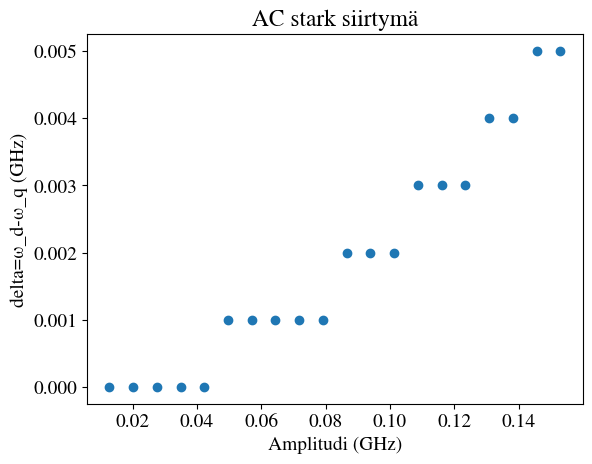

[0.0, 0.0, 0.0, 0.0, 0.0, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.003, 0.003, 0.003, 0.004, 0.004, 0.005, 0.005]


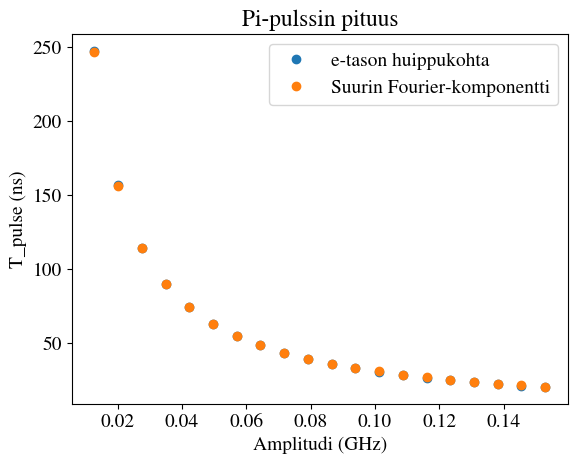

[np.float64(247.24914352088032), np.float64(156.5336053197996), np.float64(114.38046121005829), np.float64(90.22251897172701), np.float64(74.44590363240863), np.float64(63.35048552818044), np.float64(54.969487442740224), np.float64(48.80698885050477), np.float64(43.630490033026994), np.float64(39.68649093399631), np.float64(36.2340701987339), np.float64(33.276186917204605), np.float64(30.811284182596857), np.float64(28.838230666927206), np.float64(26.86638583500056), np.float64(25.387502211055576), np.float64(23.90768072211118), np.float64(22.6753260457137), np.float64(21.442130257421443), np.float64(20.45628518811471)]


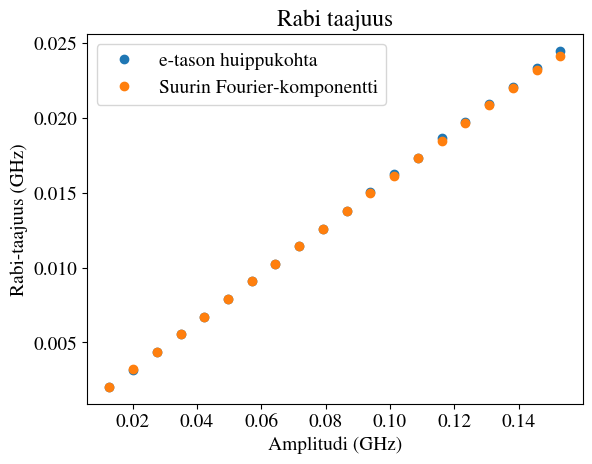

[np.float64(0.002028318451819624), np.float64(0.003202599653926633), np.float64(0.00437689425637846), np.float64(0.005551181498473184), np.float64(0.006725416797041097), np.float64(0.007899669078518402), np.float64(0.009073982416082895), np.float64(0.01024831642941099), np.float64(0.011422446386367666), np.float64(0.012596789500333305), np.float64(0.013771063182367387), np.float64(0.014945497194788845), np.float64(0.01611949782869291), np.float64(0.017293752636268218), np.float64(0.01846829191764623), np.float64(0.01964228694489724), np.float64(0.02081613833775392), np.float64(0.02199064240331499), np.float64(0.023165473470480775), np.float64(0.024096330843258313)]


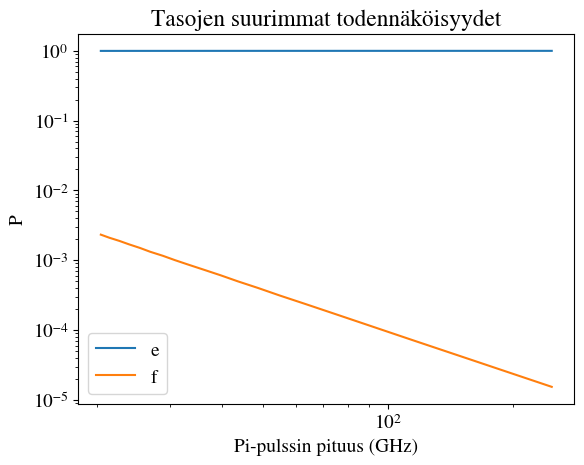

[np.float64(0.999976518577111), np.float64(0.9999415807785937), np.float64(0.9998911058312304), np.float64(0.9998250115048415), np.float64(0.9997438763846171), np.float64(0.9996912912287825), np.float64(0.9996787479538042), np.float64(0.9996188080133982), np.float64(0.9995248526276578), np.float64(0.9994027563806176), np.float64(0.9993067981383302), np.float64(0.9992028610125349), np.float64(0.9990663035407512), np.float64(0.9989297506520954), np.float64(0.9987944623861129), np.float64(0.9986306816340718), np.float64(0.9984774697648278), np.float64(0.9983046732456502), np.float64(0.9981293909837248), np.float64(0.9979377483289708)]
[np.float64(1.5372761835728926e-05), np.float64(3.8441479325621634e-05), np.float64(7.201730913463564e-05), np.float64(0.00011619279294053677), np.float64(0.00017106347136537056), np.float64(0.0002364350695057075), np.float64(0.00031291779367409765), np.float64(0.0004003570155846716), np.float64(0.0004988554398147795), np.float64(0.0006085069866972252), np.f

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.loglog(pulse_lengths, e_vals)
plt.loglog(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

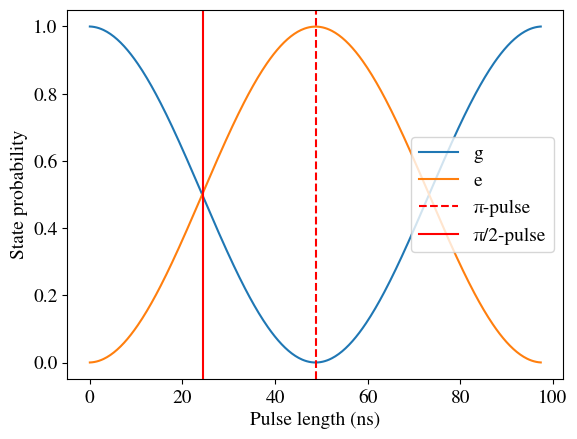

In [9]:
vals=sim_pulse(qubit.frequency+0.00093,0.0643922561418857,evolution_eigenbasis,dim,0.0643922561418857)

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])


plt.figure()
plt.plot(vals[4], g_vals)
plt.plot(vals[4], e_vals)

plt.axvline(x=48.8071228855234, ymin=0, ymax=1, color='r', ls='--', label='axvline - full height')
plt.axvline(x=48.8071228855234/2, ymin=0, ymax=1, color='r', ls='-', label='axvline - full height')

plt.legend(["g","e","π-pulse","π/2-pulse"], loc="right")
plt.xlabel("Pulse length (ns)")
plt.ylabel("State probability")
plt.show()


[-0.04, -0.0399, -0.0398, -0.0397, -0.0396, -0.0395, -0.0394, -0.0393, -0.0392, -0.0391, -0.039, -0.0389, -0.0388, -0.0387, -0.0386, -0.0385, -0.0384, -0.0383, -0.0382, -0.0381, -0.038, -0.0379, -0.0378, -0.0377, -0.0376, -0.0375, -0.0374, -0.0373, -0.0372, -0.0371, -0.037, -0.0369, -0.0368, -0.0367, -0.0366, -0.0365, -0.0364, -0.0363, -0.0362, -0.0361, -0.036, -0.0359, -0.0358, -0.0357, -0.0356, -0.0355, -0.0354, -0.0353, -0.0352, -0.0351, -0.035, -0.0349, -0.0348, -0.0347, -0.0346, -0.0345, -0.0344, -0.0343, -0.0342, -0.0341, -0.034, -0.0339, -0.0338, -0.0337, -0.0336, -0.0335, -0.0334, -0.0333, -0.0332, -0.0331, -0.033, -0.0329, -0.0328, -0.0327, -0.0326, -0.0325, -0.0324, -0.0323, -0.0322, -0.0321, -0.032, -0.0319, -0.0318, -0.0317, -0.0316, -0.0315, -0.0314, -0.0313, -0.0312, -0.0311, -0.031, -0.0309, -0.0308, -0.0307, -0.0306, -0.0305, -0.0304, -0.0303, -0.0302, -0.0301, -0.03, -0.0299, -0.0298, -0.0297, -0.0296, -0.0295, -0.0294, -0.0293, -0.0292, -0.0291, -0.029, -0.0289, -0.02

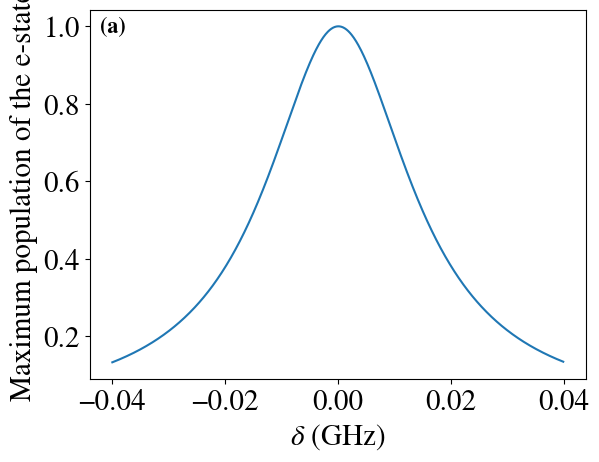

Rabi-taajuus (fourier):  0.002499986330635075


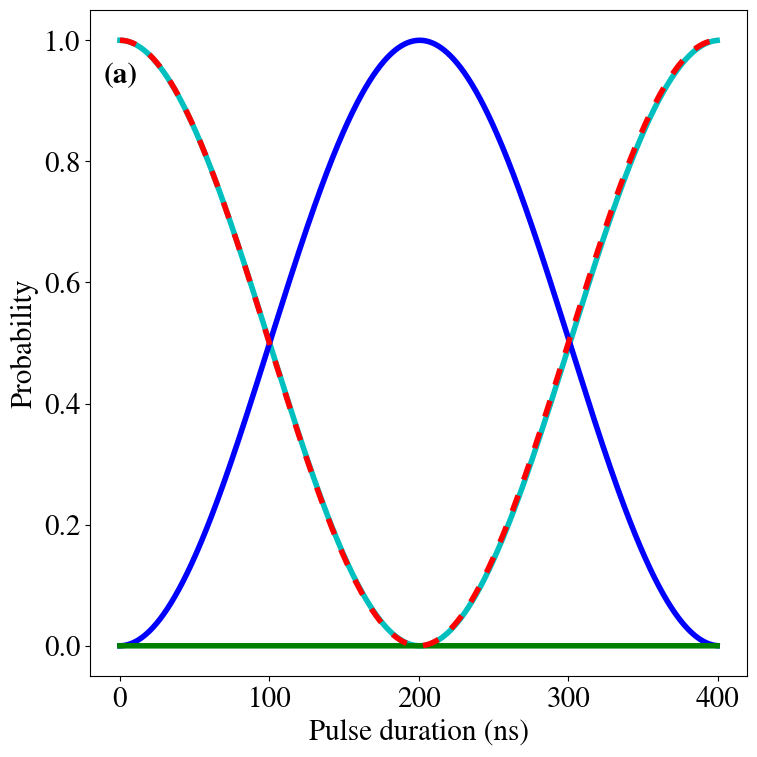

---------------------------------------------


In [10]:
A = np.pi/200

params=find_params(qubit, A, evolution_eigenbasis,A)

f_d_opt = qubit.frequency+params[0] #Löydetty optimaalinen ajotaajuus

vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,A/100)

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
T_floquet = 2*np.pi/(f_d_opt)
freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/100) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

plt.figure(figsize=(8, 8))
plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
plt.plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3, 3), linewidth=4, color='r')
plt.xlabel("Pulse duration (ns)")
plt.ylabel("Probability")
#plt.legend([r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],loc="upper right")
#print(vals[4][:n_picked])
#print(g_vals[:n_picked])
#print(f_vals[:n_picked])
#print(e_vals[:n_picked])

ax = plt.gca()

ax.text(0.02, 0.92, "(a)",
    transform=ax.transAxes,
    va="top",
    fontweight="bold")
#plt.title("Tasojen suurimmat todennäköisyydet")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("resonanssi-kantti.pdf")    
plt.show()

print("---------------------------------------------")

Rabi-taajuus (fourier):  0.002499986330635075
Rabi-taajuus (fourier):  0.002485268474919258
Rabi-taajuus (fourier):  0.002383368914020966


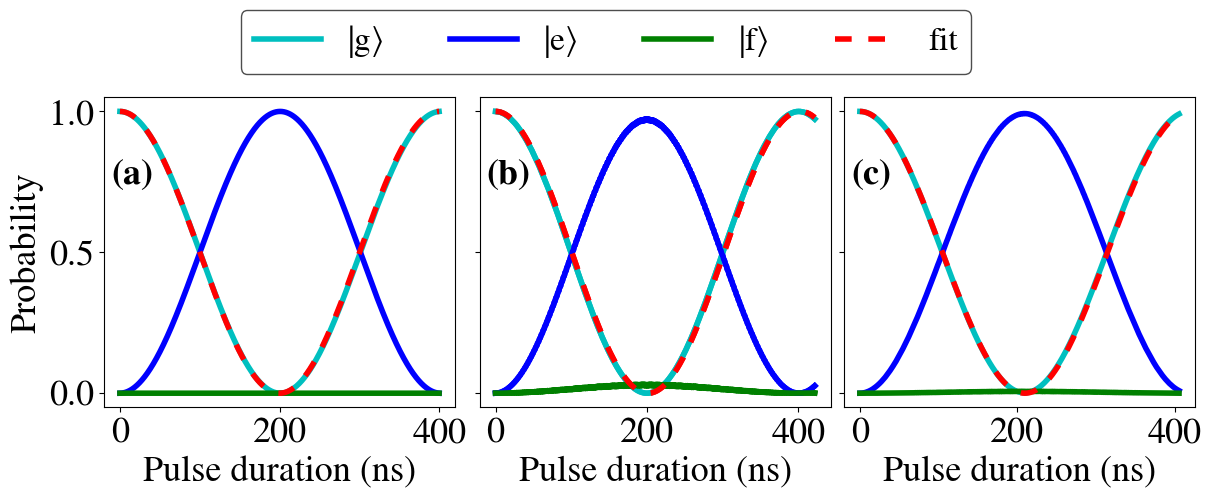

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

A = np.pi/200

params=find_params(qubit, A, evolution_eigenbasis, A)

f_d_opt = qubit.frequency+params[0] #Löydetty optimaalinen ajotaajuus

vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,A/100)

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
T_floquet = 2*np.pi/(f_d_opt)
freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/100) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

axs[0].plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
axs[0].plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
axs[0].plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
axs[0].plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3,3), linewidth=4, color='r')

axs[0].set_xlabel("Pulse duration (ns)")
axs[0].set_ylabel("Probability")
axs[0].text(0.02, 0.8, "(a)", transform=axs[0].transAxes, va="top", fontweight="bold")

A = 6.15

f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
AC_stark=-0.002324*A**2 + 0.005164 *A - 0.01915 #Arvaus AC-stark siirtymälle
params=find_params_sub(qubit, A, evolution_eigenbasis,f_rabi,AC_stark)
f_d_opt = qubit.frequency/3+params[0] #Löydetty optimaalinen ajotaajuus

m=100
T_floquet = 2*np.pi/(f_d_opt)

vals=sim_pulse_sub(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
freqs = np.fft.rfftfreq(len(vals[4]), d=T_floquet) 
"""else:
    vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
    freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) """

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

axs[1].plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
axs[1].plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
axs[1].plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
axs[1].plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3,3), linewidth=4, color='r')

l1, = axs[1].plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
l2, = axs[1].plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
l3, = axs[1].plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
l4, = axs[1].plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3, 3), linewidth=4, color='r')

axs[1].set_xlabel("Pulse duration (ns)")
axs[1].tick_params(axis='y', which='both', left=True, labelleft=False)
axs[1].text(0.02, 0.8, "(b)", transform=axs[1].transAxes, va="top", fontweight="bold")

A = 1.95

f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
c=-0.001471*A**2 - 0.001084*A + 1.002 #Arvaus c:n arvolle
params=find_params_2(qubit, A, evolution_eigenbasis,f_rabi,c)

f_1_opt = f_1*params[0]
f_2_opt = f_2*params[0]

m=100
vals=sim_pulse_2(f_1_opt,f_2_opt,A,evolution_eigenbasis,dim,f_rabi/m,K=200)

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
T_floquet = 10*np.pi/(2*f_1_opt-f_2_opt) #Floquet-jakson pituus
freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

axs[2].plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
axs[2].plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
axs[2].plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
axs[2].plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3,3), linewidth=4, color='r')

axs[2].set_xlabel("Pulse duration (ns)")
axs[2].tick_params(axis='y', which='both', left=True, labelleft=False)
axs[2].text(0.02, 0.8, "(c)", transform=axs[2].transAxes, va="top", fontweight="bold")

fig.legend(
    [l1, l2, l3, l4],
    [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=4,
    fontsize=24,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.savefig("kanttipulssit.pdf", bbox_inches="tight", pad_inches=0.1)
plt.show()